In [5]:
from nltk.tokenize import word_tokenize
from collections import Counter
import numpy as np
from scipy.optimize import curve_fit
import json
import matplotlib.pyplot as plt
import pandas as pd
import re

### Helper function

In [4]:
def remove_markdown(sentence):
    """
    Remove markdown formatting from a sentence.
    
    Args:
        sentence: Input sentence to remove markdown from
    """

    # Remove markdown formatting
    sentence = re.sub(r'#+', '', sentence)  # Remove all # symbols
    sentence = re.sub(r'\*\*', '', sentence)  # Remove **
    sentence = re.sub(r'\*', '', sentence)  # Remove *
    return sentence

# Calculate heaps' parameters (general)

In [14]:
# Heap's Law function
def heaps_law(n, K, beta):
    return K * (n ** beta)

def heaps_params_general(file_paths):

    k_list = []
    beta_list = []
    N_values_list = []
    V_values_list = []
    name_list = []

    for file_path in file_paths:

        
        with open(file_path, "r") as f:

            all_data = ""

            if file_path.split("/")[-1].split(".")[0].split("_")[-1] == "1" or file_path.split("/")[-1].split(".")[0].split("_")[-1] == "2" or file_path.split("/")[-1].split(".")[0].split("_")[-1] == "3" or file_path.split("/")[-1].split(".")[0].split("_")[-1] == "4":
            #if True:
                name = "Human" + " (" + file_path.split("/")[-1].split(".")[0] + ")"
                for line in f:
                    data = json.loads(line)
                    response_key = "response_human"

                    response = data[response_key]

                    all_data += response

            else:
                name = file_path.split("/")[-1].split(".")[0].split("_")[-1] + " (" + file_path.split("/")[5] + ", " + file_path.split("/")[-1].split(".")[0].split("_")[0] + "_" + file_path.split("/")[-1].split(".")[0].split("_")[1] + "_" + file_path.split("/")[-1].split(".")[0].split("_")[2] + ")"
                for line in f:
                    data = json.loads(line)
                    response_key = [k for k in data.keys() if k.startswith('response_')][1]

                    response = data[response_key]

                    all_data += response

        all_data = remove_markdown(all_data)
        tokens = word_tokenize(all_data.lower())


        vocab = set()
        N_values = []
        V_values = []



        # Build token stream and count V(N)
        for i in range(1000, len(tokens), 1000):  # Step can vary)
            current_tokens = tokens[:i]
            vocab.update(current_tokens)
            N_values.append(i)
            V_values.append(len(vocab))

        # Fit the curve
        params, _ = curve_fit(heaps_law, N_values, V_values)
        k, beta = params
        
        print(f"{name}: Estimated k: {k:.2f}, beta: {beta:.2f}")        
        
        k_list.append(k)
        beta_list.append(beta)
        N_values_list.append(N_values)
        V_values_list.append(V_values)
        name_list.append(name)


    return (k_list, beta_list, N_values_list, V_values_list, name_list)


# Plot heaps curves (general)

In [3]:
def plot_heaps_curves(k_list, beta_list, N_values_list, V_values_list, name_list, plot_actual_data=False):
    # Plot Heaps' Law curves
    plt.figure(figsize=(10, 6))

    colors = ['#1f77b4', '#ffb347', '#ff8c00', '#e60000', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
              '#1a5276', '#c0392b', '#27ae60', '#884ea0', '#f39c12',
              '#3498db', '#16a085', '#e74c3c', '#9b59b6', '#f1c40f',
              '#2980b9', '#8e44ad', '#2ecc71', '#e67e22', '#95a5a6']

    # Find the maximum N value across all datasets
    max_n = max([max(N_values) for N_values in N_values_list])

    if plot_actual_data:
        # Plot the actual data points
        for i in range(len(name_list)):
            plt.scatter(N_values_list[i], V_values_list[i], color=colors[i], alpha=0.005, label=f'Observed ({name_list[i]})')
    
    # Plot the fitted curve for the model
    for i in range(len(name_list)):
        # Use the same maximum N value for all curves
        x_range = np.linspace(min(N_values_list[i]), max_n, 100)
        plt.plot(x_range, heaps_law(x_range, k_list[i], beta_list[i]), color=colors[i], label=f'{name_list[i]} (k={k_list[i]:.2f}, β={beta_list[i]:.2f})')

    plt.xlabel('Number of Tokens (N)')
    plt.ylabel('Vocabulary Size (V)')
    plt.title("Heaps' Law: Vocabulary Growth")
    
    # Move the legend outside the plot to the right
    plt.legend(bbox_to_anchor=(0.05, 0.95), loc='upper left', borderaxespad=0.)
    
    plt.grid(True, alpha=0.3)
    # Adjust layout to make room for the legend
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


# Plotting heaps curves for all datasets

In [16]:
def plot_heaps_curves_all(k_list, beta_list, N_values_list, V_values_list, name_list, plot_actual_data=False):
    plt.figure(figsize=(14, 6))

    # Define two color palettes - one for humans, one for models
    human_colors = ['#1f77b4', '#4682b4', '#6ca6cd', '#87ceeb']  # Blue family
    model_colors = ['#8B0000', '#A52A2A', '#B22222', '#CD5C5C', '#DC143C',
                   '#FF0000', '#FF4500', '#FF6347', '#FF7F50', '#FA8072',
                   '#E9967A', '#F08080', '#FFA07A', '#FF6B6B', '#FF8C8C',
                   '#FFB6B6', '#FFCCCB', '#FFD4D4', '#FFE4E1', '#FFDAB9', '#FFEFD5']


    # Find the maximum N value across all datasets
    max_n = max([max(N_values) for N_values in N_values_list])

    # Create lists to store curve data for shading
    human_curves_y = []
    model_curves_y = []
    x_range = np.linspace(0, max_n, 100)

    # Plot curves with different colors for humans vs models
    for i in range(len(name_list)):
        is_human = name_list[i].startswith('Human')
        #print(i, is_human)
        color = human_colors[i] if is_human else model_colors[i - 4]  # -4 to offset after human colors
        
        # Calculate curve
        y_values = heaps_law(x_range, k_list[i], beta_list[i])
        
        # Store curves for shading
        if is_human:
            human_curves_y.append(y_values)
        else:
            model_curves_y.append(y_values)

        # Plot individual curves
        plt.plot(x_range, y_values, color=color, 
                label=f'{name_list[i]} (k={k_list[i]:.2f}, β={beta_list[i]:.2f})',
                alpha=0.8)

    plt.xlabel('Number of Tokens (N)')
    plt.ylabel('Vocabulary Size (V)')
    plt.title("Heaps' Law: Vocabulary Growth")
    
    # Move the legend outside the plot to the right with smaller font size
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., 
              fontsize='small')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

# plot_heaps_curves(heaps_params[0], heaps_params[1], heaps_params[2], heaps_params[3], heaps_params[4], plot_actual_data=False)


# Calculate heaps' curves

## Apply to all files

In [44]:
data_paths = [ # add human files
    "../../Data/Finetuning/Dolly/dolly_train_1.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_2.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_3.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_4.jsonl",
    # Small
    "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_1_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_2_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_3_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_4_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Small/Other/dolly_train_2_Gemma.jsonl",
    "../../Data/Finetuning/Augmented/Small/Other/dolly_train_3_Qwen2.5-7B-Instruct.jsonl",
    "../../Data/Finetuning/Augmented/Small/Other/dolly_train_4_Falcon3-10B-Instruct.jsonl",
    
    # Medium
    "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_1_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_2_Llama.jsonl", 
    "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_3_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_4_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_2_Mistral.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_3_Qwen.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_4_Command.jsonl",
    
    # Large
    "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_1_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_2_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_3_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_4_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl", 
    "../../Data/Finetuning/Augmented/Large/Other/dolly_train_3_GPT.jsonl",
    "../../Data/Finetuning/Augmented/Large/Other/dolly_train_4_Deepseek.jsonl",
]

In [10]:
heaps_params = heaps_params_general(data_paths)

Human (dolly_train_1): Estimated k: 9.02, beta: 0.64
Human (dolly_train_2): Estimated k: 9.71, beta: 0.64
Human (dolly_train_3): Estimated k: 8.51, beta: 0.65
Human (dolly_train_4): Estimated k: 8.39, beta: 0.65
Llama (Small, dolly_train_1): Estimated k: 19.19, beta: 0.56
Llama (Small, dolly_train_2): Estimated k: 18.86, beta: 0.56
Llama (Small, dolly_train_3): Estimated k: 19.29, beta: 0.56
Llama (Small, dolly_train_4): Estimated k: 17.51, beta: 0.57
Gemma (Small, dolly_train_2): Estimated k: 27.29, beta: 0.53
Qwen2 (Small, dolly_train_3): Estimated k: 22.14, beta: 0.55
Falcon3-10B-Instruct (Small, dolly_train_4): Estimated k: 16.42, beta: 0.58
Llama (Medium, dolly_train_1): Estimated k: 21.47, beta: 0.55
Llama (Medium, dolly_train_2): Estimated k: 19.47, beta: 0.56
Llama (Medium, dolly_train_3): Estimated k: 22.20, beta: 0.55
Llama (Medium, dolly_train_4): Estimated k: 18.76, beta: 0.56
Mistral (Medium, dolly_train_2): Estimated k: 18.84, beta: 0.57
Qwen (Medium, dolly_train_3): Esti

In [11]:
# Save parameters
# Extract dataset information from source names
sources = heaps_params[4]
datasets = []
clean_sources = []

for source in sources:
    # Check if it contains dolly_train pattern
    if 'dolly_train_' in source:
        # Extract the dataset part (dolly_train_X)
        dataset_match = re.search(r'(dolly_train_\d+)', source)
        if dataset_match:
            dataset = dataset_match.group(1)
            datasets.append(dataset)
            # Remove dataset info from source
            clean_source = re.sub(r'(?:,\s*)?dolly_train_\d+(?:\))?', '', source)
            clean_source = re.sub(r'\s*\(\s*\)', '', clean_source)  # Remove empty parentheses
        
            clean_sources.append(clean_source)
        else:
            datasets.append('')
            clean_sources.append(source)
    else:
        datasets.append('')
        clean_sources.append(source)

clean_sources = ['Human', 'Human', 'Human', 'Human', 'Llama (Small)', 'Llama (Small)', 'Llama (Small)', 'Llama (Small)', 'Gemma (Small)', 'Qwen (Small)', 'Falcon (Small)', 'Llama (Medium)', 'Llama (Medium)', 'Llama (Medium)', 'Llama (Medium)', 'Mistral (Medium)', 'Qwen (Medium)', 'Command (Medium)', 'Llama (Large)', 'Llama (Large)', 'Llama (Large)', 'Llama (Large)', 'Gemini (Large)', 'GPT (Large)', 'Deepseek (Large)']

saved_params = pd.DataFrame({
    'source': clean_sources,
    'dataset': datasets,
    'k': heaps_params[0],
    'beta': heaps_params[1],
    'N': heaps_params[2],
    'V': heaps_params[3]
})

saved_params.head(25)


,source,dataset,k,beta,N,V
0,Human,dolly_train_1,9.022604,0.644529,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[411, 784, 1141, 1467, 1783, 2038, 2276, 2533,..."
1,Human,dolly_train_2,9.710769,0.640290,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[502, 878, 1215, 1532, 1853, 2186, 2419, 2683,..."
2,Human,dolly_train_3,8.505578,0.648113,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[491, 901, 1119, 1322, 1508, 1681, 1863, 2080,..."
3,Human,dolly_train_4,8.388742,0.649836,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[457, 818, 1168, 1517, 1812, 2111, 2362, 2604,..."
4,Llama (Small),dolly_train_1,19.189088,0.558420,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[355, 677, 959, 1235, 1453, 1716, 1909, 2128, ..."
5,Llama (Small),dolly_train_2,18.862633,0.561900,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[388, 684, 972, 1278, 1549, 1792, 2028, 2261, ..."
6,Llama (Small),dolly_train_3,19.291737,0.558649,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[390, 708, 1012, 1307, 1587, 1746, 1954, 2201,..."
7,Llama (Small),dolly_train_4,17.508655,0.565768,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[427, 755, 1062, 1357, 1566, 1774, 1965, 2170,..."
8,Gemma (Small),dolly_train_2,27.285780,0.530614,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[467, 817, 1125, 1404, 1679, 1914, 2167, 2354,..."
9,Qwen (Small),dolly_train_3,22.141020,0.550583,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[453, 807, 1119, 1409, 1700, 1881, 2089, 2329,..."


In [13]:
saved_params.to_pickle("../../Data/analysis/heaps_law/parameters_v1.pkl")
saved_params = pd.read_pickle("../../Data/analysis/heaps_law/parameters_v1.pkl")

saved_params.head(25)


,source,dataset,k,beta,N,V
0,Human,dolly_train_1,9.022604,0.644529,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[411, 784, 1141, 1467, 1783, 2038, 2276, 2533,..."
1,Human,dolly_train_2,9.710769,0.640290,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[502, 878, 1215, 1532, 1853, 2186, 2419, 2683,..."
2,Human,dolly_train_3,8.505578,0.648113,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[491, 901, 1119, 1322, 1508, 1681, 1863, 2080,..."
3,Human,dolly_train_4,8.388742,0.649836,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[457, 818, 1168, 1517, 1812, 2111, 2362, 2604,..."
4,Llama (Small),dolly_train_1,19.189088,0.558420,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[355, 677, 959, 1235, 1453, 1716, 1909, 2128, ..."
5,Llama (Small),dolly_train_2,18.862633,0.561900,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[388, 684, 972, 1278, 1549, 1792, 2028, 2261, ..."
6,Llama (Small),dolly_train_3,19.291737,0.558649,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[390, 708, 1012, 1307, 1587, 1746, 1954, 2201,..."
7,Llama (Small),dolly_train_4,17.508655,0.565768,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[427, 755, 1062, 1357, 1566, 1774, 1965, 2170,..."
8,Gemma (Small),dolly_train_2,27.285780,0.530614,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[467, 817, 1125, 1404, 1679, 1914, 2167, 2354,..."
9,Qwen (Small),dolly_train_3,22.141020,0.550583,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[453, 807, 1119, 1409, 1700, 1881, 2089, 2329,..."


## Calculating average parameter values per size bracket

In [33]:
saved_params = pd.read_pickle("../../Data/analysis/heaps_law/parameters_v1.pkl")

# Average parameters for each source size bracket (and human)
avg_params = pd.DataFrame()

# Average heaps parameters for human
human_k = saved_params[saved_params["source"] == "Human"]["k"].mean()
human_beta = saved_params[saved_params["source"] == "Human"]["beta"].mean()
human_N = saved_params[saved_params["source"] == "Human"]["N"].iloc[0]
human_V = saved_params[saved_params["source"] == "Human"]["V"].iloc[0]

# Average heaps parameters for small models
small_k = saved_params[saved_params["source"].str.contains("(Small)", case=False)]["k"].mean()
small_beta = saved_params[saved_params["source"].str.contains("(Small)", case=False)]["beta"].mean()
small_N = saved_params[saved_params["source"].str.contains("(Small)", case=False)]["N"].iloc[0]
small_V = saved_params[saved_params["source"].str.contains("(Small)", case=False)]["V"].iloc[0]

# Average heaps parameters for medium models
medium_k = saved_params[saved_params["source"].str.contains("(Medium)", case=False)]["k"].mean()
medium_beta = saved_params[saved_params["source"].str.contains("(Medium)", case=False)]["beta"].mean()
medium_N = saved_params[saved_params["source"].str.contains("(Medium)", case=False)]["N"].iloc[0]
medium_V = saved_params[saved_params["source"].str.contains("(Medium)", case=False)]["V"].iloc[0]

# Average heaps parameters for large models
large_k = saved_params[saved_params["source"].str.contains("(Large)", case=False)]["k"].mean()
large_beta = saved_params[saved_params["source"].str.contains("(Large)", case=False)]["beta"].mean()
large_N = saved_params[saved_params["source"].str.contains("(Large)", case=False)]["N"].iloc[0]
large_V = saved_params[saved_params["source"].str.contains("(Large)", case=False)]["V"].iloc[0]

# Create a new DataFrame with the average parameters
avg_params = pd.DataFrame({
    "source": ["Human", "Small Models", "Medium Models", "Large Models"],
    "k": [human_k, small_k, medium_k, large_k],
    "beta": [human_beta, small_beta, medium_beta, large_beta],
    "N": [human_N, small_N, medium_N, large_N],
    "V": [human_V, small_V, medium_V, large_V]
})

# Display the aggregated parameters
avg_params.head(25)

/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_13377/277690985.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  small_k = saved_params[saved_params["source"].str.contains("(Small)", case=False)]["k"].mean()
/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_13377/277690985.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  small_beta = saved_params[saved_params["source"].str.contains("(Small)", case=False)]["beta"].mean()
/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_13377/277690985.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  small_N = saved_params[saved_params["source"].str.contains("(Small)", case=False)]["N"].iloc[0]
/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykerne

,source,k,beta,N,V
0,Human,8.906923,0.645692,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[411, 784, 1141, 1467, 1783, 2038, 2276, 2533,..."
1,Small Models,20.100313,0.557389,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[355, 677, 959, 1235, 1453, 1716, 1909, 2128, ..."
2,Medium Models,20.100490,0.557109,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[409, 737, 979, 1244, 1459, 1708, 1905, 2156, ..."
3,Large Models,22.741838,0.549296,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[398, 708, 978, 1278, 1513, 1765, 2031, 2209, ..."


In [36]:
# Save the average parameters to a pickle file
avg_params.to_pickle("../../Data/analysis/heaps_law/avg_params.pkl")
print(f"Average parameters saved to ../../Data/analysis/heaps_law/avg_params.pkl")


Average parameters saved to ../../Data/analysis/heaps_law/avg_params.pkl


## Calculating parameters for all human data stacked

In [52]:
all_dolly_human = ["../../Data/Finetuning/Dolly/dolly_train_all.jsonl"]

heaps_params_all_dolly_human = heaps_params_general(all_dolly_human)

print(heaps_params_all_dolly_human)

# Average heaps parameters for human
human_k_all_dolly = heaps_params_all_dolly_human[0][0]
human_beta_all_dolly = heaps_params_all_dolly_human[1][0]
human_N_all_dolly = heaps_params_all_dolly_human[2][0]
human_V_all_dolly = heaps_params_all_dolly_human[3][0]



# Create a new DataFrame with the average parameters
avg_params_all_dolly_human = pd.DataFrame({
    "source": ["Human", "Small Models", "Medium Models", "Large Models"],
    "k": [round(human_k_all_dolly, 2), round(small_k, 2), round(medium_k, 2), round(large_k, 2)],
    "beta": [round(human_beta_all_dolly, 2), round(small_beta, 2), round(medium_beta, 2), round(large_beta, 2)],
    "N": [human_N_all_dolly, small_N, medium_N, large_N],
    "V": [human_V_all_dolly, small_V, medium_V, large_V]
})

avg_params_all_dolly_human.head(25)

## Creating dataset with all human and all llama data stacked (separate size categories)

In [74]:
llama_paths = [
    "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_all_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_all_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_all_Llama.jsonl",
]

heaps_params_llama = heaps_params_general(llama_paths)

Llama (Small, dolly_train_all): Estimated k: 21.19, beta: 0.55
Llama (Medium, dolly_train_all): Estimated k: 25.97, beta: 0.54
Llama (Large, dolly_train_all): Estimated k: 28.26, beta: 0.53


In [76]:
# Average heaps parameters for human
human_k_all_dolly = heaps_params_all_dolly_human[0][0]
human_beta_all_dolly = heaps_params_all_dolly_human[1][0]
human_N_all_dolly = heaps_params_all_dolly_human[2][0]
human_V_all_dolly = heaps_params_all_dolly_human[3][0]

small_llama_k = heaps_params_llama[0][0]
small_llama_beta = heaps_params_llama[1][0]
small_llama_N = heaps_params_llama[2][0]
small_llama_V = heaps_params_llama[3][0]

medium_llama_k = heaps_params_llama[0][1]
medium_llama_beta = heaps_params_llama[1][1]
medium_llama_N = heaps_params_llama[2][1]
medium_llama_V = heaps_params_llama[3][1]

large_llama_k = heaps_params_llama[0][2]
large_llama_beta = heaps_params_llama[1][2]
large_llama_N = heaps_params_llama[2][2]
large_llama_V = heaps_params_llama[3][2]

# Create a new DataFrame with the average parameters
avg_params_human_llama_accumulated = pd.DataFrame({
    "source": ["Human", "Small Llama", "Medium Llama", "Large Llama"],
    "k": [round(human_k_all_dolly, 2), round(small_llama_k, 2), round(medium_llama_k, 2), round(large_llama_k, 2)],
    "beta": [round(human_beta_all_dolly, 2), round(small_llama_beta, 2), round(medium_llama_beta, 2), round(large_llama_beta, 2)],
    "N": [human_N_all_dolly, small_llama_N, medium_llama_N, large_llama_N],
    "V": [human_V_all_dolly, small_llama_V, medium_llama_V, large_llama_V]
})

avg_params_human_llama_accumulated.head(25)
# avg_params_human_llama_accumulated.to_pickle("../../Data/analysis/heaps_law/avg_params_human_llama_accumulated.pkl")

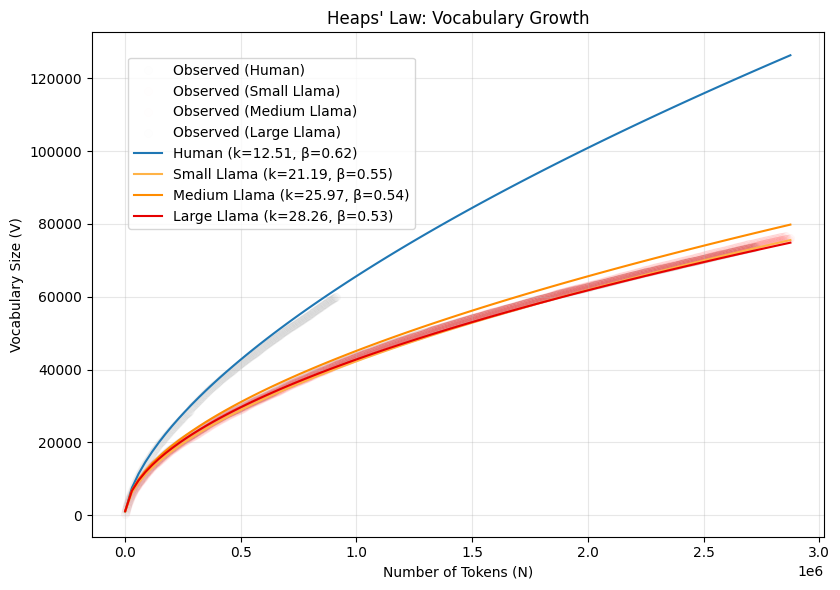

In [92]:
plot_heaps_curves(avg_params_human_llama_accumulated["k"], avg_params_human_llama_accumulated["beta"], avg_params_human_llama_accumulated["N"], avg_params_human_llama_accumulated["V"], avg_params_human_llama_accumulated["source"], plot_actual_data=True)

## Plot only curves from one size bracket

In [ ]:
parameters = pd.read_pickle("../../Data/analysis/heaps_law/parameters_v1.pkl")
parameters.head(25)



,source,dataset,k,beta,N,V
0,Human,dolly_train_1,9.022604,0.644529,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[411, 784, 1141, 1467, 1783, 2038, 2276, 2533,..."
1,Human,dolly_train_2,9.710769,0.640290,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[502, 878, 1215, 1532, 1853, 2186, 2419, 2683,..."
2,Human,dolly_train_3,8.505578,0.648113,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[491, 901, 1119, 1322, 1508, 1681, 1863, 2080,..."
3,Human,dolly_train_4,8.388742,0.649836,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[457, 818, 1168, 1517, 1812, 2111, 2362, 2604,..."
4,Llama (Small),dolly_train_1,19.189088,0.558420,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[355, 677, 959, 1235, 1453, 1716, 1909, 2128, ..."
5,Llama (Small),dolly_train_2,18.862633,0.561900,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[388, 684, 972, 1278, 1549, 1792, 2028, 2261, ..."
6,Llama (Small),dolly_train_3,19.291737,0.558649,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[390, 708, 1012, 1307, 1587, 1746, 1954, 2201,..."
7,Llama (Small),dolly_train_4,17.508655,0.565768,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[427, 755, 1062, 1357, 1566, 1774, 1965, 2170,..."
8,Gemma (Small),dolly_train_2,27.285780,0.530614,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[467, 817, 1125, 1404, 1679, 1914, 2167, 2354,..."
9,Qwen (Small),dolly_train_3,22.141020,0.550583,"[1000, 2000, 3000, 4000, 5000, 6000, 7000, 800...","[453, 807, 1119, 1409, 1700, 1881, 2089, 2329,..."


In [28]:
# Filter parameters for small, medium, and large models
parameters_small = parameters[parameters["source"].str.contains("(Small)", case=False, regex=False)].reset_index(drop=True)
parameters_small = parameters_small.drop_duplicates(subset=["source"])

parameters_medium = parameters[parameters["source"].str.contains("(Medium)", case=False, regex=False)].reset_index(drop=True)
parameters_medium = parameters_medium.drop_duplicates(subset=["source"])

parameters_large = parameters[parameters["source"].str.contains("(Large)", case=False, regex=False)].reset_index(drop=True)
parameters_large = parameters_large.drop_duplicates(subset=["source"])

parameters_human = parameters[parameters["source"].str.contains("Human", case=False, regex=False)].reset_index(drop=True)

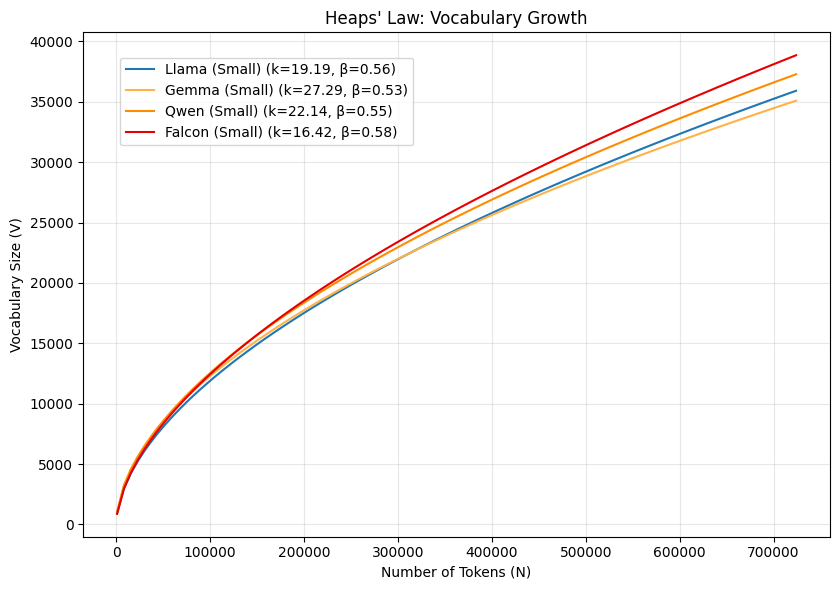

In [18]:
plot_heaps_curves(
    parameters_small["k"].values,  # Convert to numpy array
    parameters_small["beta"].values,
    parameters_small["N"].values,
    parameters_small["V"].values,
    parameters_small["source"].values,
    plot_actual_data=False
)

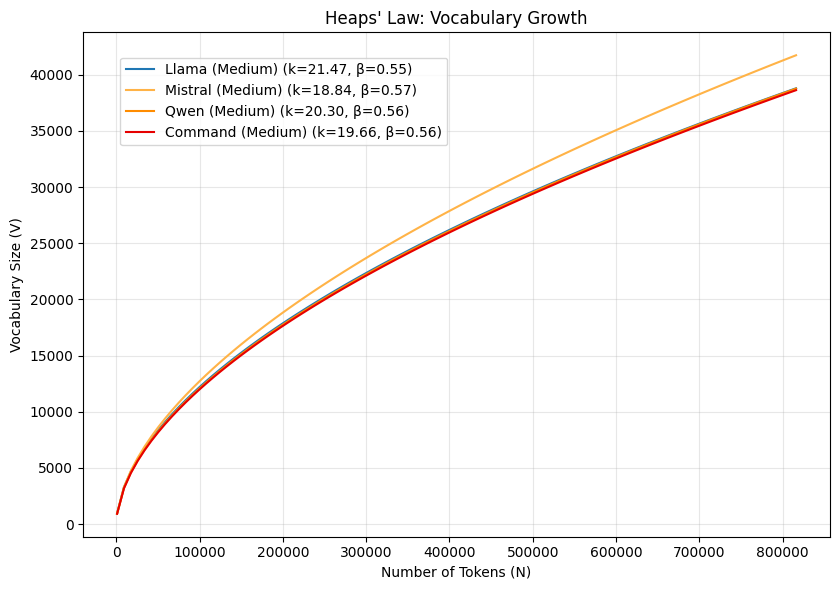

In [24]:
plot_heaps_curves(
    parameters_medium["k"].values,  # Convert to numpy array
    parameters_medium["beta"].values,
    parameters_medium["N"].values,
    parameters_medium["V"].values,
    parameters_medium["source"].values,
    plot_actual_data=False
)

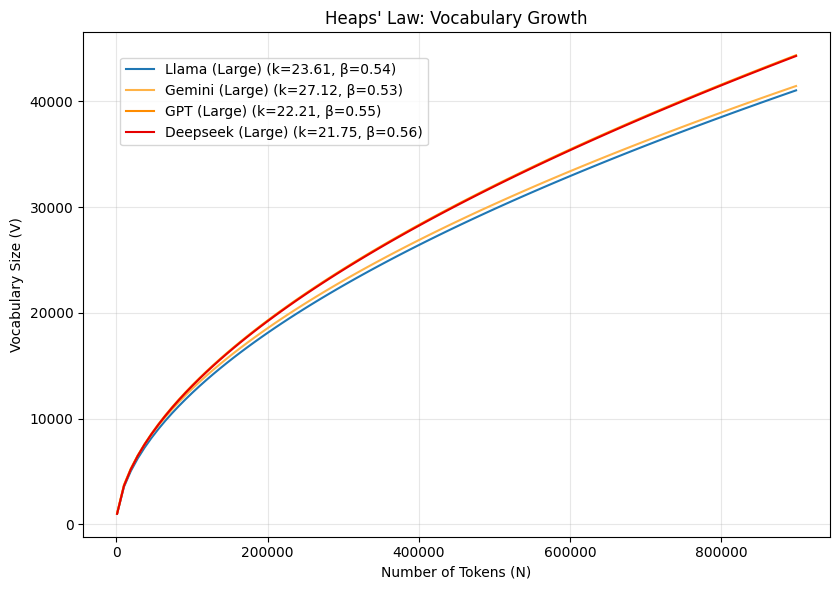

In [25]:
plot_heaps_curves(
    parameters_large["k"].values,  # Convert to numpy array
    parameters_large["beta"].values,
    parameters_large["N"].values,
    parameters_large["V"].values,
    parameters_large["source"].values, 
    plot_actual_data=False
)

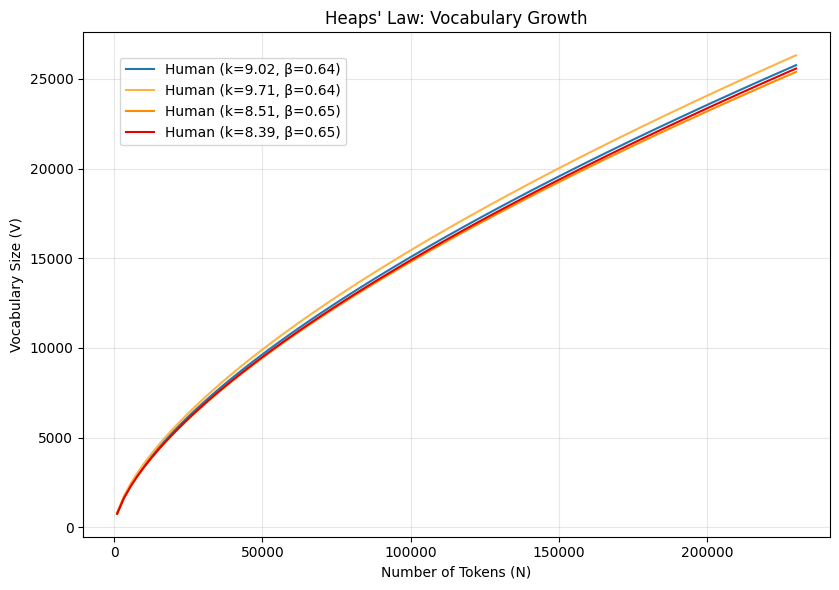

In [29]:
plot_heaps_curves(
    parameters_human["k"].values,  # Convert to numpy array
    parameters_human["beta"].values,
    parameters_human["N"].values,
    parameters_human["V"].values,
    parameters_human["source"].values, 
    plot_actual_data=False
)